# Actor-Critic Method

## Installation and Setup

In [1]:
# uncomment if needed
# %pip install "gym-classics2 @ git+https://github.com/mhahsler/gym-classics2.git"

In [2]:
import numpy as np
np.set_printoptions(precision=2)

SEED = 42
rng = np.random.default_rng(SEED)

In [3]:
import gymnasium as gym
import gym_classics2
gym_classics2.register('gymnasium')

## Define the L-Maze Grid World 

In [4]:
gym_env = gym.make('LMaze-v0', tabular = False)
env = gym_env.unwrapped
env.reset(seed=SEED)

((3, 2), {})

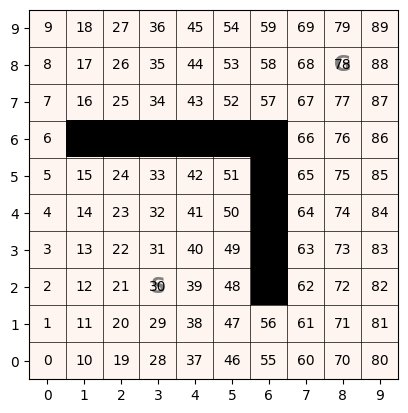

In [5]:
env.image()

## Features

Use Fourier-basis transformation and set up state features and state-action features.

In [6]:
from gym_classics2.algorithms.linear_approximation import transformation_fourier_basis, state_action_features

trans_fb = transformation_fourier_basis(min = np.array([0,0]), max = env.dims, order=2)

def state_features(s,env):
    return trans_fb(s)


## Critic: Value Function Approximation

Approximates $v$ using linear approximation:

$$\hat{v}(s,\mathbf{w}) = \mathbf{w}^\top \mathbf{x}(s),$$

where $\mathbf{x}(s)$ are state features and $\mathbf{w}$ is the weight vector we want to learn.

## Actor: Softmax in Action Preferences

Define the preference function 

$$h(s,a,\bf{\theta})=\bf{\theta}^\top \bf{x}(s,a)$$

as a linear function of the state-action features $\bf{x}(s,a)$. $\bf{\theta}$ is the weight vector we need to learn.

The stochastic policy is defined as the soft-max transformation from scores to a probability distribution: 

$$\pi(s,a,\theta) = \frac{e^{h(s,a,\bf{\theta})}}{\sum_b h(s,a,\bf{\theta})}$$

In [7]:
from gym_classics2.algorithms.policy_gradient_methods import pi

## Actor-Critic Method

We implement the simple one-step Actor-Critic Method.


![Pseudocode Actor-Critic Method](https://raw.githubusercontent.com/mhahsler/Introduction_to_Reinforcement_Learning/refs/heads/main/figures/RL-Intro_ActorCritic.png)

In [8]:
from gym_classics2.algorithms.schedules import LinearDecaySchedule, ConstantSchedule
from tqdm import tqdm

def AC(
    env,
    state_features,
    n,
    alpha_policy,
    alpha_value,
    gamma,
    max_episode_length=1000,
    verbose=False,
    history=False,
    rng=None,
    ):
    rng = np.random.default_rng(rng)
    
    if isinstance(alpha_policy, float):
        alpha_policy = ConstantSchedule(alpha_policy)
    if isinstance(alpha_value, float):
        alpha_value = ConstantSchedule(alpha_value) 
    
    state, _ = env.reset()
    
    # for simplicity we use the same features for the value function and the policy approximation
    # value function weights
    w = np.zeros(len(state_features(state, env)))
    # policy weights
    theta = np.zeros(len(state_action_features(state, 0, env, state_features)))
    
    if history:
        returns = []        
        ep_lens = []
        ws = []
        ws.append(w.copy())
        thetas = []
        thetas.append(theta.copy())
        
    for episode in tqdm(range(n), desc="Episodes", disable=verbose):
        if verbose:
            print(f"Episode {episode+1}/{n}")
        
        disc_factor = 1.0
        state, _ = env.reset()
        done = False
        i = 0
        G = 0.0
        
        while not done and  i < max_episode_length:
            # actor: select action
            a = rng.choice(env.action_space.n, p=pi(state, theta, env, state_features))
            next_state, r, done, _, _ = env.step(a)
            
            # critic: calculate estimated error + update critic
            td_error = r + gamma * np.dot(w, state_features(next_state, env)) \
                    - np.dot(w, state_features(state, env))
            w += alpha_value(episode) * td_error * state_features(state, env)
            
            # actor: update actor
            grad_log_pi = state_action_features(state, a, env, state_features) \
                    - sum([pi(state, theta, env, state_features)[b] * state_action_features(state, b, env, state_features) for b in range(env.action_space.n)])
            theta += alpha_policy(episode) * disc_factor * td_error * grad_log_pi
        
            G += disc_factor * r
            disc_factor *= gamma      
            state = next_state
            i += 1
            
        if history:
            thetas.append(theta.copy())
            ws.append(w.copy())
            returns.append(G)
            ep_lens.append(i)
            
    if history:
        return theta, w, {'thetas': thetas, 'returns': returns, 'ep_lens': ep_lens}
       
    return theta, w

In [9]:
theta, w, history = AC(env, state_features, n=1500, 
                           alpha_policy=LinearDecaySchedule(0.2, 0.001, 1000),
                           alpha_value=LinearDecaySchedule(0.2, 0.001, 1000),
                           gamma=0.99, 
                           max_episode_length = 500,
                           history=True,
                           rng=rng)

Episodes: 100%|██████████| 1500/1500 [00:11<00:00, 130.47it/s]


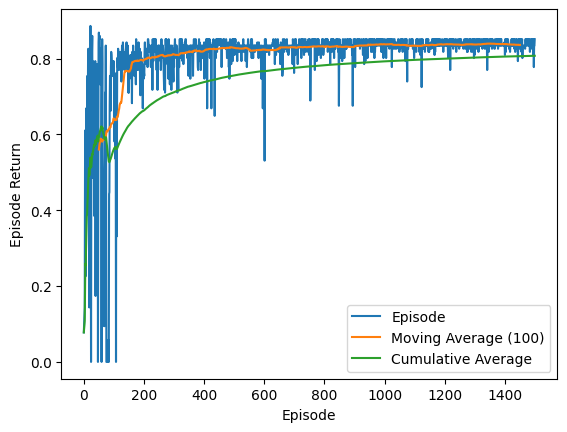

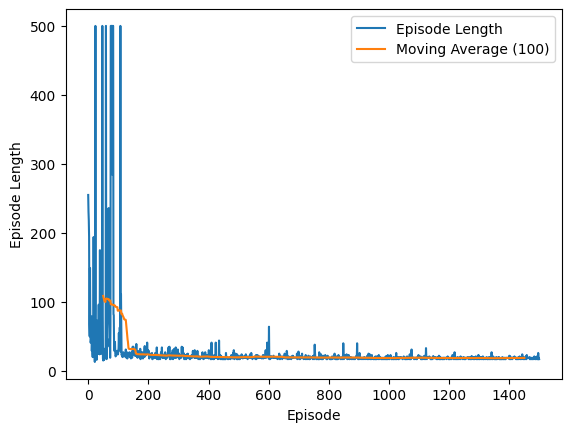

In [10]:
from gym_classics2.performance import plot_returns, plot_ep_lens
plot_returns(history['returns'])
plot_ep_lens(history['ep_lens'])

## Inspecting the Learned Models

### Critic: Learned Value Function

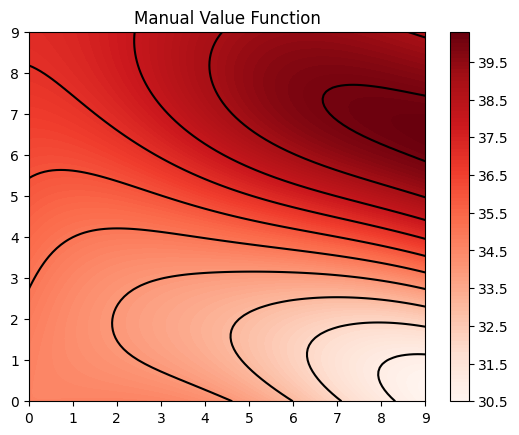

In [11]:
from matplotlib import pyplot as plt

def v_hat_grid(x, y, w):
    sf = state_features(np.array([x, y]), env)
    return np.dot(w, sf)

x = np.linspace(0, 9, 100)
y = np.linspace(0, 9, 100)
X, Y = np.meshgrid(x, y)

Z = np.array([v_hat_grid(x, y, w) for x, y in zip(np.ravel(X), np.ravel(Y))]).reshape(X.shape)

plt.contourf(X, Y, Z, cmap='Reds', levels= 100)
plt.title("Manual Value Function")
plt.colorbar()
plt.contour(X, Y, Z, colors='black', levels=10) # Contour lines
plt.show()

### Actor: Learned Policy

In [12]:
pol = [pi(env.id2state(s), theta, env, state_features) for s in env.states()]

Visualize the learned policy by showing the action with the highest probability. The probability is shown using the tile color. 
Closer to 1 means that the algorithm is more sure about the action. Smaller values means that the algorithms still would like to explore.

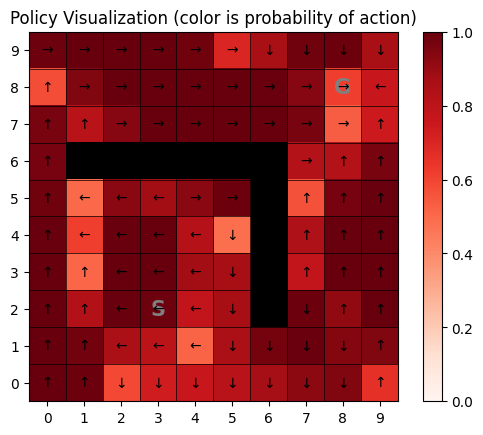

In [13]:
pol_discrete = np.argmax(pol, axis=1)
prob = np.max(pol, axis=1)
env.image(V=prob, policy=pol_discrete, title="Policy Visualization (color is probability of action)", clim = (0,1))

Visualize the found path using the highest probability action.

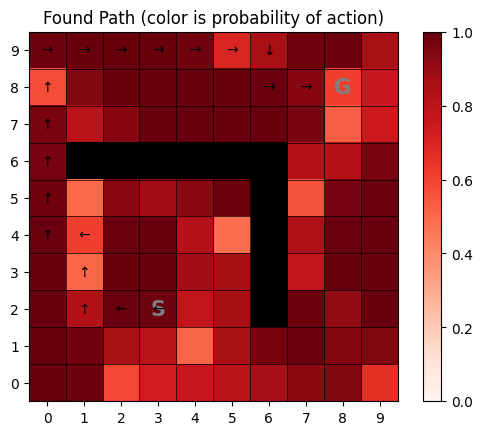

In [14]:
from gym_classics2.algorithms.monte_carlo_methods import sample_episode

path = sample_episode(env, policy=pol_discrete, max_len=100, rng=rng)
path = [(env.state2id(s), a, r,env.state2id(sp)) for s,a,r,sp in path]
env.image(V = prob, policy=pol_discrete, episode=path, title='Found Path (color is probability of action)', clim = (0,1))


&copy; 2025 [Michael Hahsler](https://michael.hahsler.net). 
This work is openly licensed under [Creative Commons Attribution-ShareAlike 4.0 International (CC BY-SA 4.0) License](https://creativecommons.org/licenses/by-sa/4.0/)

![CC BY-SA 4.0](https://licensebuttons.net/l/by-sa/3.0/88x31.png)